In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import statistics as sts 
from sklearn.preprocessing import StandardScaler,PolynomialFeatures,LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression,ElasticNet,LogisticRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,median_absolute_error,root_mean_squared_error,r2_score

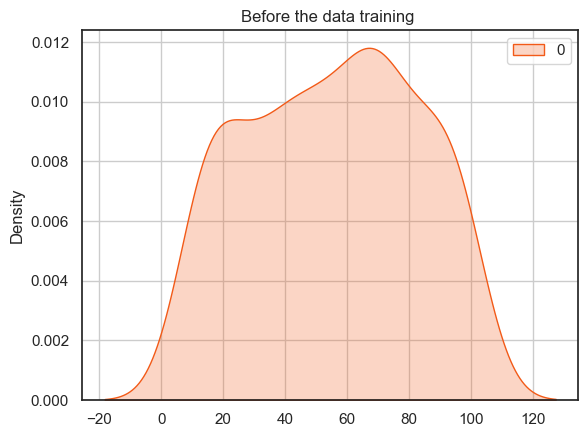

In [3]:
#data
np.random.seed(42)
x=np.random.randint(low=10,high=100,size=200).astype(int)
list1=['A','B','C','D','E']
y=np.random.choice(list1,size=200)

#storing data
data_scaler={
    "x_data":x,
    "y_data":y  
}

#framing data
dataframe1=pd.DataFrame(data=data_scaler,columns=['x_data','y_data'])
#dataframe1.sample(10)

#mapping data

dataframe1['y_data'].value_counts().to_dict()

#encoding techiques
label_encoding=LabelEncoder()
dataframe1["y_data_encoded"]=label_encoding.fit_transform(dataframe1['y_data'])

dataframe1[['x_data','y_data_encoded','y_data']]


x=dataframe1['x_data'].values.reshape(-1,1)
y=dataframe1['y_data_encoded']

#visuals before train data
col1=["#f25a18",'#ffffff']
sns.set_theme(style='white',palette=col1)
sns.kdeplot(x,fill=True)
plt.title("Before the data training ")
plt.grid(True)
plt.show()
#train and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


In [4]:
dataframe1["y_data_encoded"]

0      1
1      2
2      0
3      4
4      0
      ..
195    1
196    3
197    1
198    2
199    0
Name: y_data_encoded, Length: 200, dtype: int64

In [5]:
# Linear_reg1=LinearRegression()
# logistic_reg1=LogisticRegression()

# Linear_reg1.fit(x_train,y_train)
# y_pred1=Linear_reg1.predict(x_test)
# print(y_pred1.astype(int))

# logistic_reg1.fit(x_train,y_train)
# y_pred2=logistic_reg1.predict(x_test)
# print(y_pred2)

# from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,recall_score




In [6]:
from abc import *

class abstraction_class(ABC):
    @abstractmethod
    def printing_1(self):
        pass        
    @abstractmethod    
    def printing_2(self):
         pass
     
class concerte_class(abstraction_class):
    def printing_1(self):
        print('here is the world of ai')
    def printing_2(self):
        print('this is printing method 2 concrete class')
        
concerte_class_instance=concerte_class()
newresults=concerte_class_instance.printing_1()
print(newresults)

here is the world of ai
None


In [7]:
#CONTINOUS MODELS PIPELINES BUIDING
from codecs import ignore_errors
from sklearn.datasets import make_classification, make_regression
from sklearn.linear_model import Ridge,Lasso,ElasticNet
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import statistics as sts 
from sklearn.preprocessing import StandardScaler,MinMaxScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.metrics import (classification_report,confusion_matrix,recall_score,precision_score,
r2_score,mean_absolute_error,mean_squared_error,median_absolute_error,root_mean_squared_error)
data_frame_test1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\SupervisedLearning\09092025\testing.csv",encoding_errors='ignore',skip_blank_lines=True)

data_frame_test1.shape

data_frame_test1.sample(10)

data_frame_test2=data_frame_test1.copy()

In [8]:
data_frame_test1.sample(10)

,EmpName,EmpSalary,EmpDomain,EmpAddress,EmpHRName,EmpManagerName,EmpLocation,EmpPromotion,EmpDesignation,EmpJoinedOrNot,EmpPerFromCE,EmpScore
148,Lydia Reyes,65000,HR,"123 Oak St, Boston, MA",Olivia Park,Robert Chen,Boston HQ,No,Performance Management Specialist,Yes,81%,4.3
104,Gabriel Parker,89000,Finance,"456 Elm Ave, Austin, TX",James Wilson,Michael Brooks,Austin Office,Yes,Corporate Accountant,Yes,92%,4.8
54,Nova Griffin,67000,Marketing,"123 Oak St, Boston, MA",Olivia Park,Robert Chen,Boston HQ,No,Influencer Marketing Manager,Yes,87%,4.6
42,Finn Coleman,82000,IT,"234 Birch Ct, Portland, OR",Emma Taylor,Jason Wu,Portland Office,Yes,Security Analyst,Yes,91%,4.8
141,Arlo Fisher,87000,Engineering,"789 Pine Rd, Chicago, IL",James Wilson,Elena Rodriguez,Chicago Branch,Yes,Process Engineer,Yes,94%,4.9
115,Addison Rivera,61000,HR,"321 Cedar Ln, Denver, CO",Olivia Park,Thomas Reed,Remote - West,No,Payroll Specialist,Yes,79%,4.2
29,Luna Evans,63000,HR,"789 Pine Rd, Chicago, IL",Olivia Park,Elena Rodriguez,Chicago Branch,No,Training Coordinator,Yes,77%,4.1
58,Zoe Elliott,69000,Sales,"654 Maple Dr, Seattle, WA",Rachel Green,Amanda Foster,Seattle Tech Hub,No,Sales Support Specialist,Yes,85%,4.5
114,Theo Murphy,87000,Finance,"789 Pine Rd, Chicago, IL",James Wilson,Elena Rodriguez,Chicago Branch,Yes,Risk Analyst,Yes,92%,4.8
112,Sebastian Gray,73000,IT,"123 Oak St, Boston, MA",Sarah Mitchell,Robert Chen,Boston HQ,Yes,Full Stack Developer,Yes,87%,4.6


In [9]:
data_frame_test1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   EmpName         151 non-null    object
 1   EmpSalary       150 non-null    object
 2   EmpDomain       150 non-null    object
 3   EmpAddress      150 non-null    object
 4   EmpHRName       146 non-null    object
 5   EmpManagerName  148 non-null    object
 6   EmpLocation     150 non-null    object
 7   EmpPromotion    150 non-null    object
 8   EmpDesignation  150 non-null    object
 9   EmpJoinedOrNot  150 non-null    object
 10  EmpPerFromCE    150 non-null    object
 11  EmpScore        150 non-null    object
dtypes: object(12)
memory usage: 14.3+ KB


In [10]:
data_frame_test1.columns.to_list()

['EmpName',
 'EmpSalary',
 'EmpDomain',
 'EmpAddress',
 'EmpHRName',
 'EmpManagerName',
 'EmpLocation',
 'EmpPromotion',
 'EmpDesignation',
 'EmpJoinedOrNot',
 'EmpPerFromCE',
 'EmpScore']

In [11]:
data_frame_test2=pd.DataFrame(data=data_frame_test1,columns=[
 'EmpSalary',
'EmpPromotion'])

test3=data_frame_test2.head(60)

In [12]:
data_frame_test2.isna().sum()

EmpSalary       1
EmpPromotion    1
dtype: int64

In [13]:
data_frame_test2.drop_duplicates(inplace=True)

In [14]:
data_frame_test2.dropna(axis=1,inplace=True)

In [15]:
data_frame_test2.isna().sum()

Series([], dtype: float64)

In [16]:
data_frame_test1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   EmpName         151 non-null    object
 1   EmpSalary       150 non-null    object
 2   EmpDomain       150 non-null    object
 3   EmpAddress      150 non-null    object
 4   EmpHRName       146 non-null    object
 5   EmpManagerName  148 non-null    object
 6   EmpLocation     150 non-null    object
 7   EmpPromotion    150 non-null    object
 8   EmpDesignation  150 non-null    object
 9   EmpJoinedOrNot  150 non-null    object
 10  EmpPerFromCE    150 non-null    object
 11  EmpScore        150 non-null    object
dtypes: object(12)
memory usage: 14.3+ KB


In [17]:
test3=data_frame_test2.head(60).copy()

In [18]:
test3.columns

Index([], dtype='object')

In [19]:
test3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 0 to 75
Empty DataFrame


In [20]:
x_test=pd.to_numeric(test3['EmpSalary'],downcast='integer',errors='coerce')

KeyError: 'EmpSalary'

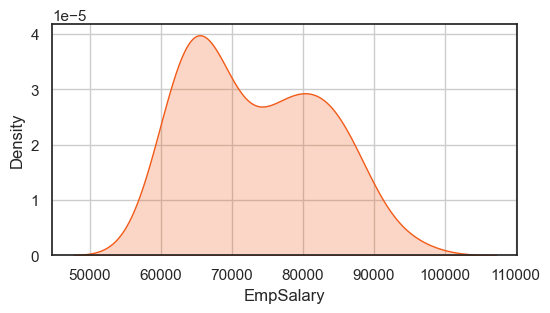

In [ ]:
colors1=["#f9b702",'#ffffff']

#Kernel plot
plt.figure(figsize=(6,3))
sns.kdeplot(x_test,fill=True)
plt.grid(True)
plt.savefig('p_test1.jpeg',dpi=1000)
plt.show()

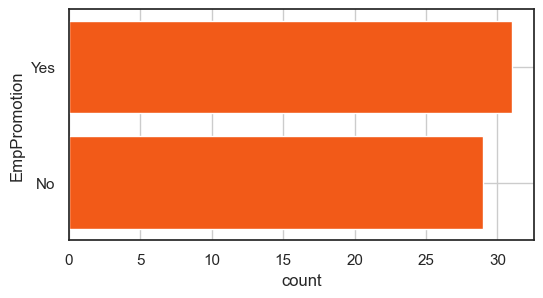

In [ ]:
plt.figure(figsize=(6,3))
sns.countplot(test3['EmpPromotion'],saturation=10)
plt.grid(True)
plt.savefig('p_test2.jpeg',dpi=1000)
plt.show()

In [ ]:
salary_ranges=test3.groupby(test3['EmpSalary']).agg(['min','max'])
salary_ranges

EmpPromotion     
                   min  max
EmpSalary                  
60000               No   No
61000               No   No
62000               No   No
63000               No   No
64000               No   No
65000               No   No
66000               No   No
67000               No   No
68000               No   No
69000               No   No
70000               No   No
72000              Yes  Yes
73000              Yes  Yes
74000              Yes  Yes
75000              Yes  Yes
76000              Yes  Yes
77000              Yes  Yes
78000              Yes  Yes
79000              Yes  Yes
80000              Yes  Yes
81000              Yes  Yes
82000              Yes  Yes
83000              Yes  Yes
84000              Yes  Yes
85000              Yes  Yes
86000              Yes  Yes
87000              Yes  Yes
88000              Yes  Yes
89000              Yes  Yes
90000              Yes  Yes
95000              Yes  Yes

In [ ]:
class Anomiles_detection:
    def __init__(self,data):
        self.data=data
    def main_function(self):
        anomile_storage=[]
        mean=sts.mean(self.data)
        std=sts.stdev(self.data)
        cutoff=3*std
        higher_bound=mean+cutoff
        lower_bound=mean-cutoff
        for each_data_anomile in self.data:
            if each_data_anomile > higher_bound or each_data_anomile < lower_bound:
                anomile_storage.append(each_data_anomile)
        return anomile_storage
    
anolies_instance=Anomiles_detection(x_test)
anomolies_data=anolies_instance.main_function()  
print(f"anomolies data {anomolies_data}")



anomolies data []


In [ ]:

linear_reg2=LinearRegression()
poly1=PolynomialFeatures(degree=4,include_bias=False)
ridge1=Ridge(alpha=1)
lasso1=Lasso(alpha=1)
elastic_net=ElasticNet(alpha=1)
model_poly1=Pipeline([
    ('Linear2',linear_reg2),
    ('poly1',poly1)
])

model_linear1=Pipeline([
    ('linear3',linear_reg2)
])

model_ridge=Pipeline([
    ('linear3',linear_reg2),
    ('ridge1',ridge1)  
])
model_lasso=Pipeline([
       ('linear3',linear_reg2),
       ('lasso1',lasso1)
])

model_elastic_net=Pipeline([
       ('linear4',linear_reg2),
       ('elastic_net1',elastic_net) 
])

dict_models={
    "linear_model":model_linear1,
    "polynomial1":model_poly1,
     "ridge":model_ridge,
     "Lasso":model_lasso,
     "elastic_net":model_elastic_net
}

for name,model in dict_models.items():
    print(f"model name is : {name}")
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)



NameError: name 'LinearRegression' is not defined